In [1]:
import os, sys
import json
import polars as pl
import numpy as np
from db_robust_clust.plots import clustering_MDS_plot_multiple_methods
import seaborn as sns
sns.set_style('whitegrid')

In [ ]:
DATA_ID = 'heart_disease' 

project_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')) 
results_dir = os.path.join(project_path, 'results', 'experiment_5', DATA_ID)
filename = f'results_exp_5_{DATA_ID}.pkl'
results_path = os.path.join(results_dir, filename)

sys.path.append(project_path)

from src.utils.experiments_exploration_utils import process_experiment_5_results, plot_experiment_5_results, fast_mds
from src.utils.simulations_utils import generate_simulation
from config.config_simulations import SIMULATION_CONFIGS
from config.config_experiment_5 import CONFIG_EXPERIMENT, N_REALIZATIONS, PROP_ERRORS_THRESHOLD

config_experiment = CONFIG_EXPERIMENT[DATA_ID]

In [ ]:
not_feasible_methods_to_add = []

df, df_avg, not_feasible_methods, results = process_experiment_5_results(
    results_path=results_path, 
    not_feasible_methods_to_add=None,
    prop_errors_threshold=PROP_ERRORS_THRESHOLD,
)

✅ Archivo cargado correctamente. Tipo de objeto: <class 'dict'>
📊 Número de realizaciones (seeds) capturadas: 100


In [4]:
df

random_state,model_name,time,adj_accuracy,ARI,status,status_error
i64,str,f64,f64,f64,str,bool
6863,"""KMeans""",0.397639,0.575758,0.019499,"""OK""",false
6863,"""CLARA""",0.076134,0.548822,0.006038,"""OK""",false
6863,"""Diana""",0.006555,0.579125,0.021481,"""OK""",false
6863,"""LDAKmeans""",0.308177,0.525253,-0.000851,"""OK""",false
6863,"""SubKmeans""",0.099442,0.575758,0.019499,"""OK""",false
…,…,…,…,…,…,…
30032,"""FoldFastKmedoidsGGower-robust_…",1.713902,0.750842,0.248994,"""OK""",false
30032,"""FastKmedoidsGGower-robust_maha…",0.496859,0.818182,0.402914,"""OK""",false
30032,"""FoldFastKmedoidsGGower-robust_…",2.783732,0.703704,0.162597,"""OK""",false


In [5]:
df_avg

model_name,mean_ari,mean_adj_accuracy,mean_time,std_ari,std_adj_accuracy,std_time,prop_status_error
str,f64,f64,f64,f64,f64,f64,f64
"""FastKmedoidsGGower-robust_maha…",0.367619,0.803502,0.520695,0.042575,0.018308,0.073836,0.0
"""FastKmedoidsGGower-robust_maha…",0.366607,0.802997,0.543122,0.045683,0.019746,0.122164,0.0
"""FastKmedoidsGGower-robust_maha…",0.361187,0.800976,0.335902,0.03708,0.016044,0.064668,0.0
"""FastKmedoidsGGower-robust_maha…",0.261853,0.751684,0.514427,0.099923,0.052841,0.085482,0.0
"""FastKmedoidsGGower-robust_maha…",0.258329,0.75,0.542236,0.099897,0.052523,0.11923,0.0
…,…,…,…,…,…,…,…
"""AgglomerativeClustering""",0.001792,0.538721,0.003187,0.0,0.0,0.00078,0.0
"""Birch""",0.001792,0.538721,0.01604,0.0,0.0,0.001657,0.0
"""GaussianMixture""",-0.002124,0.525253,0.018311,0.0,0.0,0.009496,0.0


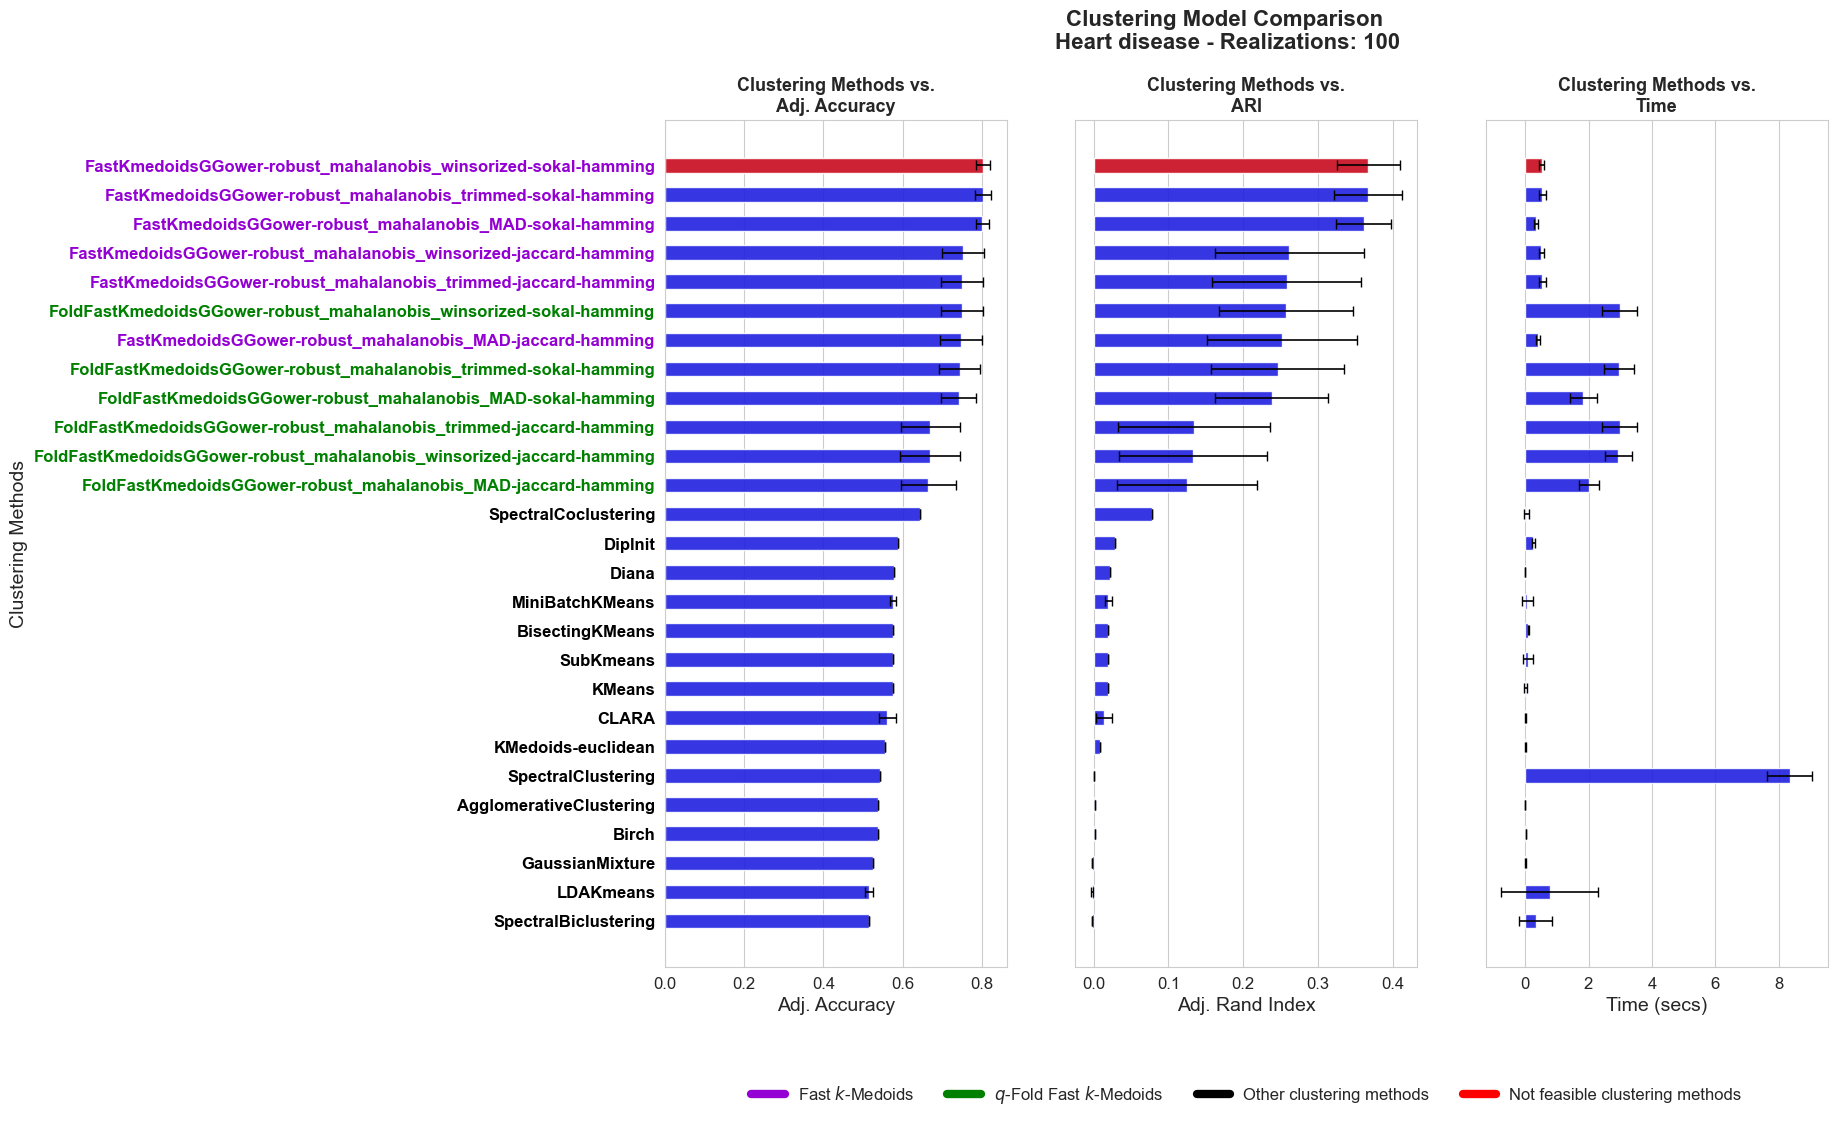

In [6]:
model_names = df_avg['model_name'].unique().to_list()
our_methods_1 = [x for x in model_names if 'Fast' in x and 'Fold' not in x] # Fast k-medoids
our_methods_2 = [x for x in model_names if 'Fast' in x and 'Fold' in x] # q-Fold Fast k-medoids
other_methods = [x for x in model_names if x not in our_methods_1 + our_methods_2 and x not in not_feasible_methods]
plot_filename = f'plot_results_exp_5_{DATA_ID}.png'
save_path = os.path.join(results_dir, plot_filename)

plot_experiment_5_results(
    df_avg = df_avg, 
    data_name = DATA_ID, 
    num_realizations = N_REALIZATIONS, 
    save_path = save_path, 
    our_methods_1=our_methods_1, our_methods_2=our_methods_2, 
    other_methods=other_methods, not_feasible_methods=not_feasible_methods)

In [ ]:
random_state_mds = 6863  
random_state_sample = 100

d1 = 'robust_mahalanobis'
d2 = 'sokal'
d3 = 'hamming'
robust_method = 'winsorized'

data_filename = f'{DATA_ID}_processed.parquet'
metadata_filename = f'metadata_{DATA_ID}.json'
processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
metadata_path = os.path.join(processed_data_dir, metadata_filename)
processed_data_path = os.path.join(processed_data_dir, data_filename)
with open(metadata_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)
    data = pl.read_parquet(processed_data_path)
    X = data[metadata['quant_predictors'] + metadata['binary_predictors'] + metadata['multiclass_predictors']]
    y = data[metadata['response']]
    config_experiment.update({
        'p1': metadata['p1'],
            'p2': metadata['p2'],
                'p3': metadata['p3']
                })
                
X_mds, sample_idx = fast_mds(
    sample_size=X.shape[0], 
    X=X, 
    d1=d1, d2=d2, d3=d3, robust_method=robust_method, 
    random_state_mds=random_state_mds, 
    random_state_sample=random_state_sample,
    config_experiment=config_experiment
)

sorted_methods_accuracy = df_avg['model_name'].to_list()

our_methods_1_sorted_acc = [x for x in list(sorted_methods_accuracy) if x in our_methods_1]
our_methods_2_sorted_acc = [x for x in list(sorted_methods_accuracy) if x in our_methods_2]
other_methods_sorted_acc = [x for x in list(sorted_methods_accuracy) if x in other_methods]
best_our_methods_1 = our_methods_1_sorted_acc[0]
best_our_methods_2 = our_methods_2_sorted_acc[0]
best_other_methods = other_methods_sorted_acc[0]
additional_methods = ['KMeans', 'CLARA']

methods_to_plot = [best_our_methods_1, best_our_methods_2, best_other_methods] + additional_methods
names_to_plot = [('Best Fast k-medoids' if x in our_methods_1 else 'Best q-Fold Fast k-medoids' if x in our_methods_2 else x) for x in methods_to_plot]
names_to_plot = dict(zip(methods_to_plot, names_to_plot))
y_pred_dict = {names_to_plot[method]: results[random_state_mds]['adj_labels'][method][sample_idx] for method in methods_to_plot}
accuracy_dict = {names_to_plot[method]: results[random_state_mds]['adj_accuracy'][method] for method in methods_to_plot}
time_dict = {names_to_plot[method]: results[random_state_mds]['time'][method] for method in methods_to_plot}

c:\Users\fscielzo\Documents\PhD\paper-2\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


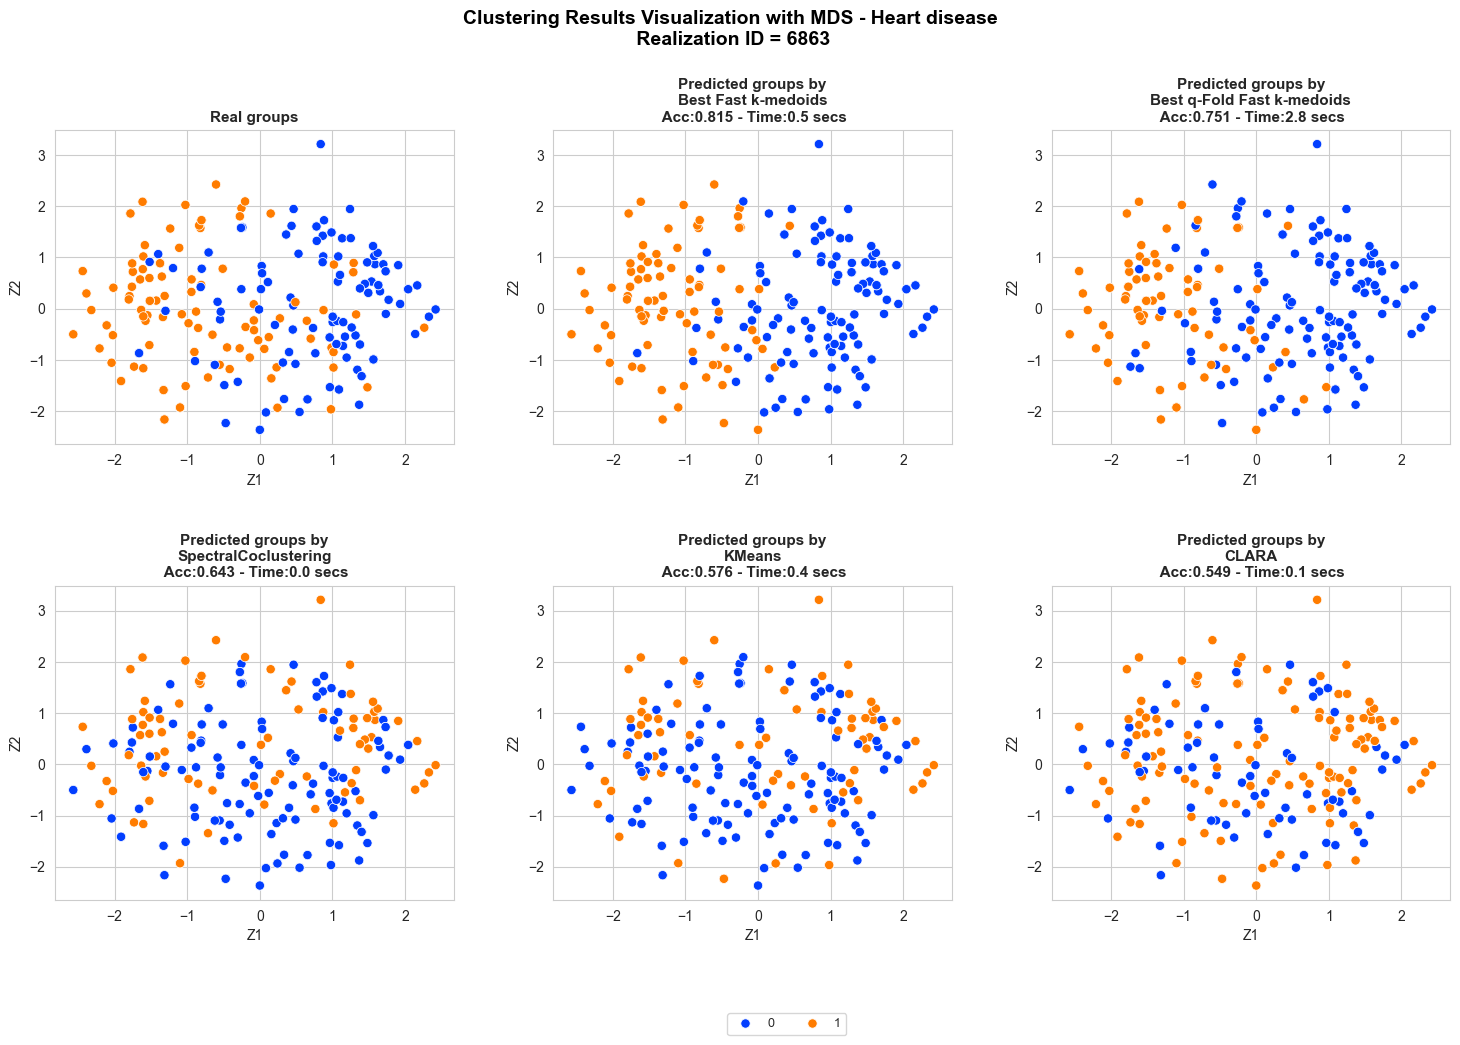

In [8]:
plot_filename = f'mds_plot_results_exp_5_{DATA_ID}.png'
save_path = os.path.join(results_dir, plot_filename)
formatted_data_name = DATA_ID.replace('_', ' ').capitalize()

clustering_MDS_plot_multiple_methods(X_mds=X_mds, y_pred=y_pred_dict, 
                                     y_true=y[sample_idx],
                                     title=f"Clustering Results Visualization with MDS - {formatted_data_name}\n Realization ID = {random_state_mds}", 
                                     accuracy=accuracy_dict, time=time_dict, n_rows=2,
                                     figsize=(18,10), bbox_to_anchor=(0.75,-1.9), 
                                     title_size=14, title_weight='bold', 
                                     subtitles_size=11,
                                     points_size=45, title_height=1, 
                                     wspace=0.25, hspace=0.45, 
                                     n_cols_legend=2, legend_title='', legend_size=9, 
                                     save = True, file_name = save_path
)
